# <u>Quadratic Discriminant Analysis (QDA)</u>

## Topics

* [0. What is QDA](#what)
* [1. Key Difference from LDA](#diff)
* [2. Model Formulation](#model)
* [3. Decision Function](#function)
* [4. Decision Boundaries](#boundary)
* [5. Parameters to estimate](#parameters)
* [6. Classification rule](#rule)
* [7. QDA implementation](#implement)
* [8. Advantages](#adv)
* [9. Disadvantages](#disadv)
* [10. Intuition](#qda)
* [11. Quick Comparison (QDA vs LDA)](#compare)
* [12. QDA library](#library)

In [ ]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
from scipy.stats import multivariate_normal # for multivariate normal pdf
from scipy.stats import norm # for normal pdf
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis # for QDA
print("Setup complete")

Setup complete


<a class="anchor" id="what"></a>
# 0. What is QDA

- Quadratic Discriminant Analysis (QDA) is a generative classification method
- Like LDA, it uses Bayes’ theorem to compute class probabilities:

$$
p(y=k \mid x) \propto p(x \mid y=k)\pi_k
$$

**It assumes that each class follows a multivariate Gaussian distribution.**

<a class="anchor" id="diff"></a>
# 1. Key Difference from LDA

- LDA assumption: all classes share the same covariance matrix $\Sigma$
- QDA assumption: each class has its own covariance matrix $\Sigma_k$

&#128073; This is the defining aspect of QDA.

<a class="anchor" id="model"></a>
# 2. Model Formulation

For each class $k$:
- Mean: $\mu_k \in \mathbb{R}^p$ for each class
- Covariance: $\Sigma_k \in \mathbb{R}^{p \times p}$ for each class

Class-conditional density:
$$
p(x \mid y=k)=\frac{1}{(2\pi)^{p/2} \det(\Sigma_k)^{1/2}} \exp(-\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k))
$$

- $p$ being number of features / dimensions

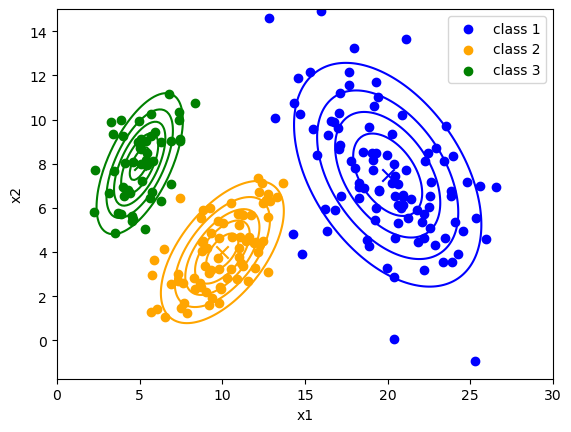

In [40]:
np.random.seed(1414)

n1, n2, n3 = 100, 75, 50

mean_1 = np.array([20, 7.5])
cov_1 = np.array([[10, -4],
                  [-4, 8]])

mean_2 = np.array([10, 4])
cov_2 = np.array([[4, 2],
                  [2, 3]]) # very different covariance structure

mean_3 = np.array([5, 8])
cov_3 = np.array([[2, 1.5],
                  [1.5, 3]]) # very different covariance structure

# generate data
class_1 = np.random.multivariate_normal(mean_1, cov_1, n1)
class_2 = np.random.multivariate_normal(mean_2, cov_2, n2)
class_3 = np.random.multivariate_normal(mean_3, cov_3, n3)

# scatter plot
plt.scatter(class_1[:,0], class_1[:,1], color="blue", label="class 1")
plt.scatter(mean_1[0], mean_1[1], marker="x", color="blue", s=80)

plt.scatter(class_2[:,0], class_2[:,1], color="orange", label="class 2")
plt.scatter(mean_2[0], mean_2[1], marker="x", color="orange", s=80)

plt.scatter(class_3[:,0], class_3[:,1], color="green", label="class 3")
plt.scatter(mean_3[0], mean_3[1], marker="x", color="green", s=80)

plt.legend()

# 2D grid (correct!)
x1 = np.linspace(0, 30, 200)
x2 = np.linspace(0, 15, 200)
X1, X2 = np.meshgrid(x1, x2)

# stack into (grid_x, grid_y, 2)
pos = np.dstack((X1, X2))

# distributions
rv1 = multivariate_normal(mean_1, cov_1)
rv2 = multivariate_normal(mean_2, cov_2)
rv3 = multivariate_normal(mean_3, cov_3)

# contours
plt.contour(X1, X2, rv1.pdf(pos), colors='blue', levels=5)
plt.contour(X1, X2, rv2.pdf(pos), colors='orange', levels=5)
plt.contour(X1, X2, rv3.pdf(pos), colors='green', levels=5)

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

<a class="anchor" id="function"></a>
# 3. Decision Function

- Because all classes have different covariance matrices, the resulting decision boundaries are quadratic (hyperplanes)
- The classifier can be written as: $$\underbrace{f_k(x)=w_{0k} + x^\top w_k + x^\top W_k x}_{\text{quadratic function of }x} \hspace{1 mm} \text{ for }k=1,\ldots,g $$
- &#128073; Because of the term $x^\top W_kx$, the boundary is quadratic (curved).

- For $g=2$ a single discriminant function $f(x)=f_1(x)-f_0(x)=(w_{01} + x^\top w_1 + x^\top W_1 x)-(w_{00} + x^\top w_0 + x^\top W_0 x)=x^\top(W_1-W_0)x+(w_1 - w_0)^\top x + (w_{01}-w_{00})$ for \{0,1\} response (or $f(x)=f_{+1}(x)-f_{-1}(x)$ for \{-1,+1\} response) is enough and then if $f(x) > 0 \rightarrow$ class 1 else $\rightarrow$ class 0.
    - Solve for either dimension of $x=\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ to get descision boundary
    $$
    \begin{align*}
    x^\top(W_1-W_0)x+(w_1 - w_0)^\top x + (w_{01}-w_{00}) &=0  \\ 
    A = W_1 - W_0,\quad w = w_1 - w_0,\quad b = w_{01}-w_{00} \\ \Leftrightarrow
    x^\top A x+ w^\top x + b &=0 \\ \Leftrightarrow
    x=\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}, \quad A=\begin{pmatrix} a_{11} & a_{12} \\ a_{12} & a_{22} \end{pmatrix}, \quad w=\begin{pmatrix} w_1 \\ w_2 \end{pmatrix}  \\ \Leftrightarrow
    x^\top A x + w^\top x + b &= 0 \\ \Leftrightarrow
    a_{11}x_1^2 + 2 a_{12}x_1x_2 + a_{22}x_2^2 + w_1x_1 + w_2x_2 + b &= 0 \\ \Leftrightarrow
    a_{22}x_2^2 + (2a_{12}x_1 + w_2)x_2 + (a_{11}x_1^2 + w_1x_1+ b) &= 0 \\ 
    \text{This is a quadratic equation in }x_2
    \\ \Rightarrow x_2 = \frac{-(2a_{12}x_1 + w_2) \pm \sqrt{(2a_{12}x_1 + w_2)^2- 4a_{22}(a_{11}x_1^2 + w_1x_1+ b)}}{2a_{22}}
    \end{align*}
    $$

- For multiclasses $g > 2$ the classifier assigns $h(x)=\hat{y}=\underset{k \in \{1,\ldots,g\}}{\arg\max} f_k(x)$
    - &#128073; So the decision boundary is where two classes are tied: $f_k(x)=f_j(x)$ for any $(k,j)$ pair $(k \neq j)$
    - For each pair of classes $k$ and $j$, the boundary is: 
    $$
    \begin{align*}
    f_k(x)-f_j(x)=0 \\
    \end{align*}
    $$ 
    - So with $g$ classes:
        - We get $\frac{g(g-1)}{2}$ boundaries
        - Each boundary separates two classes



Derivation:

$$
\begin{align*}
p(y=k \mid x) &= \frac{p(x \mid y=k)\pi_k}{p(x)} \\

&= \frac{p(x \mid y=k)\pi_k}{\sum_{j=1}^g p(x \mid y=j)p(y=j)} \\

&= \frac{p(x \mid y=k)\pi_k}{\sum_{j=1}^g p(x \mid y=j)\pi_j} \\

&\propto p(x \mid y=k)\pi_k \\

&= \frac{1}{(2\pi)^{p/2} \det(\Sigma_k)^{1/2}} \exp\left(-\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)\right)\pi_k \\

&\propto \frac{1}{\det(\Sigma_k)^{1/2}} \exp\left(-\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)\right)\pi_k \\

&= \det(\Sigma_k)^{-1/2} \exp\left(-\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)\right)\pi_k \\

&= \log\left(\det(\Sigma_k)^{-1/2} \exp\left(-\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)\right)\pi_k\right) \\

&= \log(\pi_k) + \log(\det(\Sigma_k)^{-1/2}) + \log\left(\exp\left( -\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)\right)\right) \\

&= \log(\pi_k) -\frac{1}{2} \log(\det(\Sigma_k))  -\frac{1}{2} (x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k) \\

&= \log(\pi_k) -\frac{1}{2} \log(\det(\Sigma_k)) - \frac{1}{2}x^\top \Sigma_k^{-1} x + \frac{1}{2}x^\top \Sigma_k^{-1}\mu_k + \frac{1}{2}\mu_k^\top \Sigma_k^{-1}x - \frac{1}{2}\mu_k^\top \Sigma_k^{-1}\mu_k \\

&x^\top\Sigma_k^{-1}\mu_k=\mu_k^\top \Sigma_k^{-1}x\\

&= \log(\pi_k) -\frac{1}{2} \log(\det(\Sigma_k)) - \frac{1}{2}x^\top \Sigma_k^{-1} x + \frac{1}{2}x^\top \Sigma_k^{-1}\mu_k + \frac{1}{2}\mu_k^\top \Sigma_k^{-1}x - \frac{1}{2}\mu_k^\top \Sigma_k^{-1}\mu_k \\

&= \log(\pi_k) -\frac{1}{2} \log(\det(\Sigma_k)) - \frac{1}{2}x^\top \Sigma_k^{-1} x + x^\top \Sigma_k^{-1}\mu_k - \frac{1}{2}\mu_k^\top \Sigma_k^{-1}\mu_k \\

&= \underbrace{\log(\pi_k) -\frac{1}{2} \log(\det(\Sigma_k)) - \frac{1}{2}\mu_k^\top \Sigma_k^{-1}\mu_k}_{w_{0k}}  + x^\top \underbrace{\Sigma_k^{-1}\mu_k}_{w_k} + x^\top \underbrace{\left(- \frac{1}{2} \right) \Sigma_k^{-1}}_{W_k} x  \\

&= w_{0k} + x^\top w_k + x^\top W_k x  =: f_k(x)

\end{align*}
$$

<a class="anchor" id="boundary"></a>
# 4. Decision Boundaries

- QDA produces non-linear (quadratic) decision boundaries
- In 1D, this can lead to interval-based classification (multiple cut points)
- n higher dimensions, boundaries are curved surfaces

<a class="anchor" id="parameters"></a>
# 5. Parameters to estimate

Estimated from training data:

Class priors: $$\hat{\pi}_k=\frac{n_k}{n}$$


- $n$ is total number of observations
- $n_k$ number observation in class $k$

Class means: $$\hat{\mu}_k=\frac{1}{n_k} \sum_{i:y^{(i)}=k} x^{(i)}$$


Class covariance: $$\hat{\Sigma}=\frac{1}{n_k-1}  \sum_{i:y^{(i)}=k} (x^{(i)}-\hat{\mu}_k)(x^{(i)}-\hat{\mu}_k)^\top$$




<a class="anchor" id="rule"></a>
# 6. Classification rule

- Compute a score for each class: $$f_k(x)$$
- Predict the class with the highest score: $$h(x)=\hat{y}=\underset{k \in \{1,\ldots,g\}}{\arg\max} f_k(x)$$



<a class="anchor" id="implement"></a>
# 7. QDA implementation

QDA Accuracy: 1.0


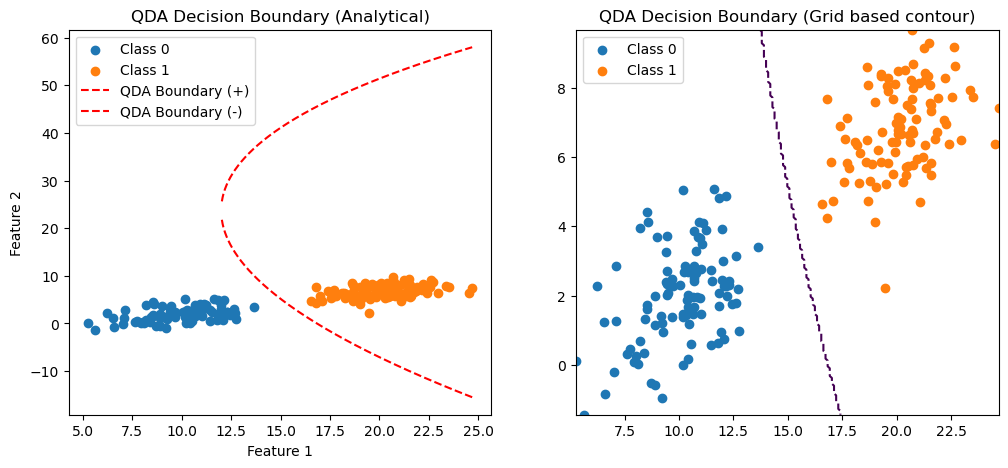

In [41]:
# Train function
def qda_fit(X, y):
    classes = np.unique(y)
    n, p = X.shape

    pi = {}
    mu = {}
    Sigma = {}
    Sigma_inv = {}

    # Priors, means, covariances
    for k in classes:
        Xk = X[y == k]

        pi[k] = len(Xk) / n
        mu[k] = np.mean(Xk, axis=0)

        # class-specific covariance
        diff = Xk - mu[k]
        Sigma[k] = (diff.T @ diff) / (len(Xk) - 1)
        Sigma_inv[k] = np.linalg.inv(Sigma[k])

    # Precompute parameters
    w = {}
    w0 = {}
    W = {}

    for k in classes:
        w[k] = Sigma_inv[k] @ mu[k]
        w0[k] = (
            np.log(pi[k])
            - 0.5 * np.log(np.linalg.det(Sigma[k]))
            - 0.5 * mu[k].T @ Sigma_inv[k] @ mu[k]
        )
        W[k] = -0.5 * Sigma_inv[k]

    return {
        "classes": classes,
        "pi": pi,
        "mu": mu,
        "Sigma": Sigma,
        "Sigma_inv": Sigma_inv,
        "w": w,
        "w0": w0,
        "W": W
    }

# Prediction function
def qda_predict(model, X):
    classes = model["classes"]
    w = model["w"]
    w0 = model["w0"]
    W = model["W"]

    preds = []
    for x in X:
        scores = {}
        for k in classes:
            scores[k] = (
                w0[k]
                + x @ w[k]
                + x @ W[k] @ x
            )
        preds.append(max(scores, key=scores.get))

    return np.array(preds)


# Probabilities function
def qda_predict_proba(model, X):
    classes = model["classes"]
    w = model["w"]
    w0 = model["w0"]
    W = model["W"]

    probs = []
    for x in X:
        scores = np.array([
            w0[k] + x @ w[k] + x @ W[k] @ x
            for k in classes
        ])

        exp_scores = np.exp(scores - np.max(scores))  # stability trick
        probs.append(exp_scores / np.sum(exp_scores))

    return np.array(probs)

# Toy data
np.random.seed(1428)
X1 = np.random.multivariate_normal([10, 2], [[3, 1], [1, 2]], 100)
X2 = np.random.multivariate_normal([20, 7], [[3, 1], [1, 2]], 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

model_qda = qda_fit(X, y)

preds_qda = qda_predict(model_qda, X)

print("QDA Accuracy:", np.mean(preds_qda == y))



# Extract parameters
W1 = model_qda["W"][1]
W0 = model_qda["W"][0]

w1 = model_qda["w"][1]
w0 = model_qda["w"][0]

w01 = model_qda["w0"][1]
w00 = model_qda["w0"][0]

# Differences
A = W1 - W0
w = w1 - w0
b = w01 - w00

a11 = A[0, 0]
a12 = A[0, 1]
a22 = A[1, 1]

w1_, w2_ = w[0], w[1]

x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Discriminant
D = (2 * a12 * x_vals + w2_)**2 - 4 * a22 * (a11 * x_vals**2 + w1_ * x_vals + b)

# Only keep real solutions
mask = D >= 0

x_valid = x_vals[mask]
D_valid = D[mask]

# Two branches
y_plus = (-(2 * a12 * x_valid + w2_) + np.sqrt(D_valid)) / (2 * a22)
y_minus = (-(2 * a12 * x_valid + w2_) - np.sqrt(D_valid)) / (2 * a22)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

# Plot both branches
plt.plot(x_valid, y_plus, 'r--', label="QDA Boundary (+)")
plt.plot(x_valid, y_minus, 'r--', label="QDA Boundary (-)")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("QDA Decision Boundary (Analytical)")
plt.legend()


# Create grid
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predict on grid
Z = qda_predict(model_qda, grid)
Z = Z.reshape(xx.shape)

# Plot
plt.subplot(1,2,2)
plt.contour(xx, yy, Z, levels=[0.5], linestyles="--")

# Scatter data
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

plt.title("QDA Decision Boundary (Grid based contour)")
plt.legend()
plt.show()

QDA Accuracy: 1.0


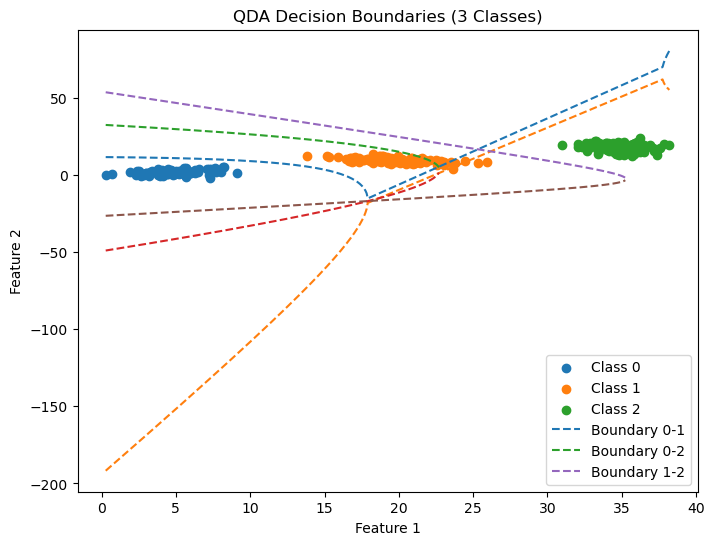

In [42]:
np.random.seed(2202)

X1 = np.random.multivariate_normal([5, 2], [[3, 1], [1, 2]], 100)
X2 = np.random.multivariate_normal([20, 10], [[5, -2], [-2, 3]], 100)
X3 = np.random.multivariate_normal([35, 18], [[2, 0], [0, 6]], 100)

X = np.vstack([X1, X2, X3])
y = np.array([0]*100 + [1]*100 + [2]*100)

# Train QDA
model_qda = qda_fit(X, y)

preds_qda = qda_predict(model_qda, X)
print("QDA Accuracy:", np.mean(preds_qda == y))

plt.figure(figsize=(8,6))

# Scatter data
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], label="Class 2")

classes = model_qda["classes"]

# Loop over all class pairs
for i in range(len(classes)-1):
    for j in range(i+1, len(classes)):
        k1 = classes[i]
        k2 = classes[j]

        # Extract parameters
        W1 = model_qda["W"][k1]
        W2 = model_qda["W"][k2]

        w1 = model_qda["w"][k1]
        w2 = model_qda["w"][k2]

        w01 = model_qda["w0"][k1]
        w02 = model_qda["w0"][k2]

        # Differences
        A = W2 - W1
        w_diff = w2 - w1
        b = w02 - w01

        # Coefficients
        a11 = A[0, 0]
        a12 = A[0, 1]
        a22 = A[1, 1]

        w1_, w2_ = w_diff[0], w_diff[1]

        # x-axis values
        x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

        # Discriminant
        D = (2 * a12 * x_vals + w2_)**2 - 4 * a22 * (a11 * x_vals**2 + w1_ * x_vals + b)

        # Only real solutions
        mask = D >= 0

        x_valid = x_vals[mask]
        D_valid = D[mask]

        # Avoid division by zero
        if np.abs(a22) < 1e-8:
            continue

        # Two branches
        y_plus = (-(2 * a12 * x_valid + w2_) + np.sqrt(D_valid)) / (2 * a22)
        y_minus = (-(2 * a12 * x_valid + w2_) - np.sqrt(D_valid)) / (2 * a22)

        # Plot both branches
        plt.plot(x_valid, y_plus, '--', label=f"Boundary {k1}-{k2}")
        plt.plot(x_valid, y_minus, '--')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("QDA Decision Boundaries (3 Classes)")
plt.legend()
plt.show()

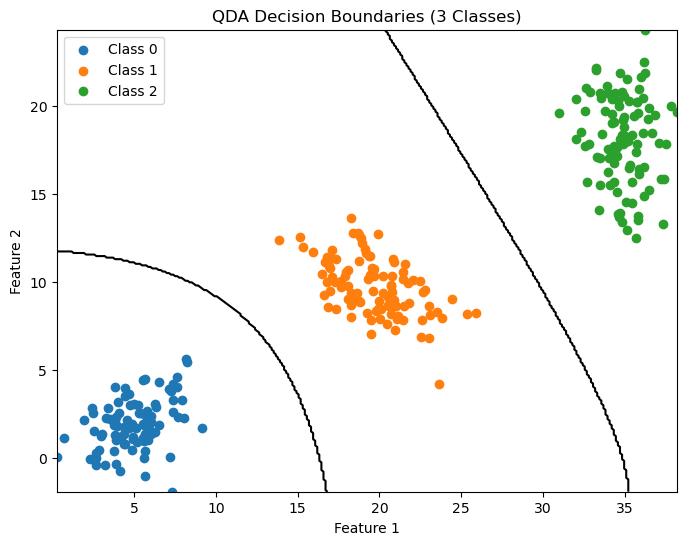

In [43]:
plt.figure(figsize=(8,6))

# Scatter data
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], label="Class 2")

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 300),
    np.linspace(X[:,1].min(), X[:,1].max(), 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = qda_predict(model_qda, grid) # use grid-based contour instead of analytical descision boundary (more stable)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5, 1.5], colors='black')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("QDA Decision Boundaries (3 Classes)")
plt.legend()
plt.show()

In [44]:
# Generate 3D toy data 
np.random.seed(1918)

mean1 = [10, 2, 5]
mean2 = [20, 7, 15]

cov = [[3, 1, 0.5],
       [1, 2, 0.3],
       [0.5, 0.3, 2]]

X1 = np.random.multivariate_normal(mean1, cov, 100)
X2 = np.random.multivariate_normal(mean2, cov, 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

model_qda = qda_fit(X, y)

# Extract parameters
W1 = model_qda["W"][1]
W0 = model_qda["W"][0]

w1 = model_qda["w"][1]
w0 = model_qda["w"][0]

w01 = model_qda["w0"][1]
w00 = model_qda["w0"][0]

# Differences
A = W1 - W0
w = w1 - w0
b = w01 - w00

x_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)
z_range = np.linspace(X[:,2].min(), X[:,2].max(), 30)

xx, yy, zz = np.meshgrid(x_range, y_range, z_range)

grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

f_vals = np.array([
    x @ A @ x + w @ x + b
    for x in grid
])

f_vals = f_vals.reshape(xx.shape)

fig = go.Figure()

# Class 0
fig.add_trace(go.Scatter3d(
    x=X[y==0][:,0],
    y=X[y==0][:,1],
    z=X[y==0][:,2],
    mode='markers',
    name='Class 0'
))

# Class 1
fig.add_trace(go.Scatter3d(
    x=X[y==1][:,0],
    y=X[y==1][:,1],
    z=X[y==1][:,2],
    mode='markers',
    name='Class 1'
))

# QDA decision boundary (f(x) = 0 surface)
fig.add_trace(go.Isosurface(
    x=xx.flatten(),
    y=yy.flatten(),
    z=zz.flatten(),
    value=f_vals.flatten(),
    isomin=0,
    isomax=0,
    surface_count=1,
    showscale=False,
    showlegend=True,
    colorscale="blues",
    opacity=0.5,
    caps=dict(x_show=False, y_show=False, z_show=False),
    name='QDA Boundary'
))

fig.update_layout(
    title="3D QDA Decision Boundary",
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Feature 3'
    )
)

fig.show()

<a class="anchor" id="adv"></a>
# 8. Advantages

### Advantages of QDA over LDA
- More flexible than LDA $\rightarrow$ better fit when class distributions differ
- Captures complex, non-linear class boundaries


### Advantages of LDA over QDA
- Simple and computationally efficient
- Works well when Gaussian assumption is reasonable
- Requires estimating fewer parameters than QDA
    - Requires estimating $\frac{p(p+1)}{2}$ parameters for $\hat{\Sigma}$ 
- Better in high dimensions

<a class="anchor" id="disadv"></a>
# 9. Disadvantages

### Disadvantages of QDA 
- Requires estimating many more parameters:
    - Requires estimating $g \cdot \frac{p(p+1)}{2}$ parameters for $\hat{\Sigma}$ ($g$ is number of classes)
- Can perform worse than LDA in high dimensions with limited data.


### Disadvantages of LDA 
- Less flexible
- Assumes equal covariance structure

<a class="anchor" id="qda"></a>
# 10. Intuition

- QDA lets each class have its own shape and orientation in feature space
- Classification is based on which Gaussian distribution the point most likely comes from
- More flexibility $\rightarrow$ better fit but higher variance

<a class="anchor" id="compare"></a>
# 11. Quick Comparison (QDA vs LDA)

| Feature          | LDA    | QDA            |
| ---------------- | ------ | -------------- |
| Covariance       | Shared | Class-specific |
| Boundary         | Linear | Quadratic      |
| Flexibility      | Lower  | Higher         |
| Data requirement | Lower  | Higher         |




<a class="anchor" id="library"></a>
# 12. QDA library

```python
# 1. Quadratic Discriminant Analysis (scikit-learn)
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Basic model
model1 = QuadraticDiscriminantAnalysis(
    priors=None, # class priors (default: inferred from data)
    reg_param=0.0, # regularization of covariance (0 = no regularization)
    store_covariance=False, # whether to store covariance matrices
    tol=1e-4 # threshold for rank estimation
)

model1.fit(X, y)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy
model1.means_ # class means
model1.covariance_ if model1.store_covariance else None  # covariances (if enabled)


# 2. QDA with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "reg_param": [0.0, 0.1, 0.3, 0.5, 0.9], # regularization strength
    "store_covariance": [False, True]
}

model2 = GridSearchCV(
    estimator=QuadraticDiscriminantAnalysis(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_


# 3. QDA with Regularization (important for stability)
model3 = QuadraticDiscriminantAnalysis(
    reg_param=0.1 # helps when covariance matrices are ill-conditioned
)

model3.fit(X, y)
model3.score(X, y)


# 4. QDA with custom class priors
import numpy as np

priors = np.array([0.3, 0.4, 0.3])  # must sum to 1

model4 = QuadraticDiscriminantAnalysis(
    priors=priors,
    reg_param=0.1
)

model4.fit(X, y)
model4.score(X, y)


# 5. Inspect class-specific parameters
model5 = QuadraticDiscriminantAnalysis(store_covariance=True)
model5.fit(X, y)

model5.means_ # class means
model5.covariance_ # class-specific covariance matrices
model5.priors_ # estimated priors
```



Accuracy: 0.9933333333333333
Class means:
 [[ 5.22698338  1.96918812]
 [15.19863476  9.86897816]
 [24.83177759  4.73023327]]
Class priors:
 [0.33333333 0.33333333 0.33333333]


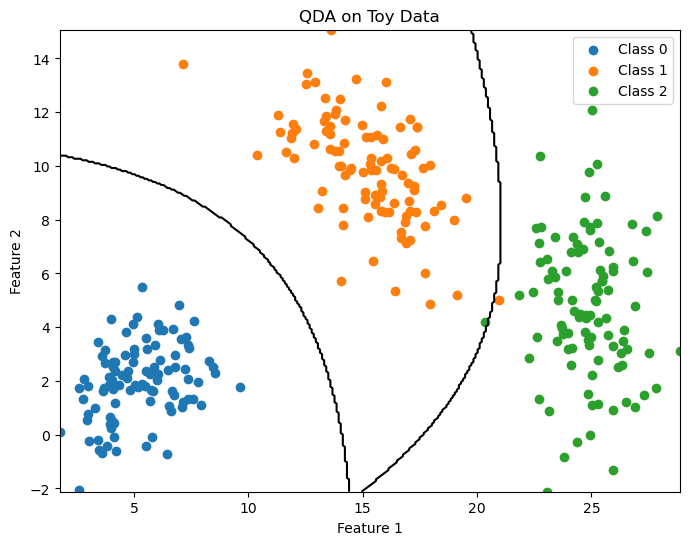

In [46]:
np.random.seed(1529)

n = 100

mean_1 = [5, 2]
cov_1  = [[3, 1],
          [1, 2]]

mean_2 = [15, 10]
cov_2  = [[5, -2],
          [-2, 3]]

mean_3 = [25, 5]
cov_3  = [[2, 0],
          [0, 6]]

X1 = np.random.multivariate_normal(mean_1, cov_1, n)
X2 = np.random.multivariate_normal(mean_2, cov_2, n)
X3 = np.random.multivariate_normal(mean_3, cov_3, n)

X = np.vstack([X1, X2, X3])
y = np.array([0]*n + [1]*n + [2]*n)

# Fit QDA model 
model = QuadraticDiscriminantAnalysis(reg_param=0.05)
model.fit(X, y)

# 3. Evaluate 
print("Accuracy:", model.score(X, y))
print("Class means:\n", model.means_)
print("Class priors:\n", model.priors_)

# 4. Plot data 
plt.figure(figsize=(8,6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0")
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1")
plt.scatter(X[y==2][:,0], X[y==2][:,1], label="Class 2")

# Plot decision boundaries (grid-based, robust) 
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 300),
    np.linspace(X[:,1].min(), X[:,1].max(), 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5, 1.5], colors='black')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("QDA on Toy Data")
plt.legend()
plt.show()